In [ ]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
SESSION_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "multimodal_emotion_pipeline.py").exists() else NOTEBOOK_DIR / "Session-4"
if str(SESSION_DIR) not in sys.path:
    sys.path.append(str(SESSION_DIR))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

import multimodal_emotion_pipeline as mer

DATA_ROOT = SESSION_DIR
CACHE_DIR = DATA_ROOT / "cache"
TRANSCRIPT_CSV = DATA_ROOT/"transcripts.csv"

runtime = mer.assert_runtime_ready(DATA_ROOT)
mer.set_seed(42)
device = mer.get_device()
runtime, device

({'has_librosa': True,
  'has_soundfile': True,
  'has_whisper': True,
  'ffmpeg_path': None,
  'data_root': 'd:\\IIT Hyderabad\\EPOCH_spring_camp\\main\\EPOCH-spring-camp\\Session-4',
  'data_root_exists': True,
  'actor_dir_count': 24,
  'wav_file_count': 2880},
 device(type='cpu'))

In [ ]:
audio_config = mer.AudioConfig()
train_config = mer.TrainingConfig(epochs=20, batch_size=32, lr=1e-3, random_seed=42)
df = mer.build_metadata(DATA_ROOT)
display(df.head())
display(mer.summarize_dataset(df))

for note in mer.dataset_challenges(df):
    print("-", note)

,path,stem,modality,vocal_channel,emotion_code,emotion,label,intensity,statement,repetition,actor_id,gender
0,d:\IIT Hyderabad\EPOCH_spring_camp\main\EPOCH-...,03-01-01-01-01-01-01,03,01,01,neutral,0,1,1,1,1,male
1,d:\IIT Hyderabad\EPOCH_spring_camp\main\EPOCH-...,03-01-01-01-01-02-01,03,01,01,neutral,0,1,1,2,1,male
2,d:\IIT Hyderabad\EPOCH_spring_camp\main\EPOCH-...,03-01-01-01-02-01-01,03,01,01,neutral,0,1,2,1,1,male
3,d:\IIT Hyderabad\EPOCH_spring_camp\main\EPOCH-...,03-01-01-01-02-02-01,03,01,01,neutral,0,1,2,2,1,male
4,d:\IIT Hyderabad\EPOCH_spring_camp\main\EPOCH-...,03-01-02-01-01-01-01,03,01,02,calm,1,1,1,1,1,male


,samples,actors,female_samples,male_samples
emotion,,,,
angry,192,24,96,96
calm,192,24,96,96
disgust,192,24,96,96
fearful,192,24,96,96
happy,192,24,96,96
sad,192,24,96,96
surprised,192,24,96,96
neutral,96,24,48,48


- Class imbalance exists: neutral has 96 clips while most emotions have 192.
- Only 2 spoken sentences are repeated across the whole dataset, so transcript-only learning is weak by design.
- Random splits can leak speaker-specific traits from train to test, so actor-aware evaluation is worth checking after the main experiment.
- The dataset is small for deep learning, which makes regularization, caching, and careful validation more important.


In [ ]:
df = mer.transcribe_dataset(df, TRANSCRIPT_CSV, model_name="tiny")
mer.warn_if_transcripts_look_constant(df)
display(df[["stem", "emotion", "transcript"]].head(10))

,stem,emotion,transcript
0,03-01-01-01-01-01-01,neutral,Kids are talking by the door.
1,03-01-01-01-01-02-01,neutral,Kids are talking by the door.
2,03-01-01-01-02-01-01,neutral,Dogs are sitting by the door.
3,03-01-01-01-02-02-01,neutral,Dogs are sitting by the door.
4,03-01-02-01-01-01-01,calm,Kids are talking by the door.
5,03-01-02-01-01-02-01,calm,Kids are talking by the door.
6,03-01-02-01-02-01-01,calm,Dogs are sitting by the door.
7,03-01-02-01-02-02-01,calm,Dogs are sitting by the door.
8,03-01-02-02-01-01-01,calm,Kids are talking by the door.
9,03-01-02-02-01-02-01,calm,Kids are talking by the door.


In [5]:
train_df, val_df, test_df = mer.create_splits(df, seed=train_config.random_seed)
train_df, val_df, test_df, vocab = mer.attach_text_features(
    train_df,
    val_df,
    test_df,
    max_length=16,
    min_freq=1,
)

mer.cache_audio_features(df, CACHE_DIR, audio_config)
class_weights = mer.compute_class_weights_tensor(train_df["label"].to_numpy(), device)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Vocabulary size: {len(vocab)}")
print("Class weights:", class_weights.detach().cpu().numpy())

Train: 1152 | Val: 144 | Test: 144
Vocabulary size: 125
Class weights: [1.8701298 0.9350649 0.9350649 0.9350649 0.9411765 0.9411765 0.9350649
 0.9411765]


In [6]:
audio_train_loader = DataLoader(
    mer.AudioEmotionDataset(train_df, audio_config, cache_dir=None, augment=True),
    batch_size=train_config.batch_size,
    shuffle=True,
)
audio_val_loader = DataLoader(
    mer.AudioEmotionDataset(val_df, audio_config, cache_dir=CACHE_DIR, augment=False),
    batch_size=train_config.batch_size,
    shuffle=False,
)
audio_test_loader = DataLoader(
    mer.AudioEmotionDataset(test_df, audio_config, cache_dir=CACHE_DIR, augment=False),
    batch_size=train_config.batch_size,
    shuffle=False,
)

text_train_loader = DataLoader(
    mer.TextEmotionDataset(train_df),
    batch_size=train_config.batch_size,
    shuffle=True,
)
text_val_loader = DataLoader(
    mer.TextEmotionDataset(val_df),
    batch_size=train_config.batch_size,
    shuffle=False,
)
text_test_loader = DataLoader(
    mer.TextEmotionDataset(test_df),
    batch_size=train_config.batch_size,
    shuffle=False,
)

fusion_train_loader = DataLoader(
    mer.MultimodalEmotionDataset(train_df, audio_config, cache_dir=CACHE_DIR, augment=False),
    batch_size=train_config.batch_size,
    shuffle=True,
)
fusion_val_loader = DataLoader(
    mer.MultimodalEmotionDataset(val_df, audio_config, cache_dir=CACHE_DIR, augment=False),
    batch_size=train_config.batch_size,
    shuffle=False,
)
fusion_test_loader = DataLoader(
    mer.MultimodalEmotionDataset(test_df, audio_config, cache_dir=CACHE_DIR, augment=False),
    batch_size=train_config.batch_size,
    shuffle=False,
)

sample_audio, sample_label = next(iter(audio_train_loader))
sample_text, _ = next(iter(text_train_loader))
print("Audio batch:", sample_audio.shape)
print("Text batch:", sample_text.shape)
print("Labels:", sample_label.shape)

Audio batch: torch.Size([32, 1, 64, 130])
Text batch: torch.Size([32, 16])
Labels: torch.Size([32])


In [7]:
audio_model = mer.AudioCNN(num_classes=len(mer.EMOTION_NAMES))
audio_history = mer.train_model(
    audio_model,
    audio_train_loader,
    audio_val_loader,
    device=device,
    epochs=train_config.epochs,
    lr=train_config.lr,
    weight_decay=train_config.weight_decay,
    class_weights=class_weights,
)

audio_probs, y_true = mer.predict_probabilities(audio_model, audio_test_loader, device)
audio_metrics = mer.evaluate_probabilities(y_true, audio_probs)
print(f"Audio CNN accuracy: {audio_metrics['accuracy']:.4f}")
print(f"Audio CNN weighted F1: {audio_metrics['weighted_f1']:.4f}")

Epoch 01/20 | train_loss=2.0304 | val_loss=1.9522
Epoch 05/20 | train_loss=1.5853 | val_loss=1.7897
Epoch 10/20 | train_loss=1.3676 | val_loss=1.5894
Epoch 15/20 | train_loss=1.2091 | val_loss=1.4470
Epoch 20/20 | train_loss=1.0487 | val_loss=1.3520
Audio CNN accuracy: 0.4931
Audio CNN weighted F1: 0.4703


In [8]:
text_model = mer.TextGRU(vocab_size=len(vocab), num_classes=len(mer.EMOTION_NAMES))
text_history = mer.train_model(
    text_model,
    text_train_loader,
    text_val_loader,
    device=device,
    epochs=train_config.epochs,
    lr=train_config.lr,
    weight_decay=train_config.weight_decay,
    class_weights=class_weights,
)

text_probs, y_true_text = mer.predict_probabilities(text_model, text_test_loader, device)
assert np.array_equal(y_true, y_true_text)
text_metrics = mer.evaluate_probabilities(y_true_text, text_probs)
print(f"Text GRU accuracy: {text_metrics['accuracy']:.4f}")
print(f"Text GRU weighted F1: {text_metrics['weighted_f1']:.4f}")

Epoch 01/20 | train_loss=2.0878 | val_loss=2.0760
Epoch 05/20 | train_loss=2.0432 | val_loss=2.0872
Epoch 10/20 | train_loss=2.0052 | val_loss=2.0862
Epoch 15/20 | train_loss=1.9733 | val_loss=2.0799
Epoch 20/20 | train_loss=1.9488 | val_loss=2.0845
Text GRU accuracy: 0.1319
Text GRU weighted F1: 0.0741


In [9]:
early_fusion_model = mer.EarlyFusionModel(
    audio_model=audio_model,
    text_model=text_model,
    num_classes=len(mer.EMOTION_NAMES),
    freeze_backbones=True,
)

fusion_history = mer.train_model(
    early_fusion_model,
    fusion_train_loader,
    fusion_val_loader,
    device=device,
    epochs=15,
    lr=1e-3,
    weight_decay=1e-4,
    class_weights=class_weights,
)

early_fusion_probs, y_true_fusion = mer.predict_probabilities(early_fusion_model, fusion_test_loader, device)
assert np.array_equal(y_true, y_true_fusion)
early_fusion_metrics = mer.evaluate_probabilities(y_true_fusion, early_fusion_probs)
print(f"Early fusion accuracy: {early_fusion_metrics['accuracy']:.4f}")
print(f"Early fusion weighted F1: {early_fusion_metrics['weighted_f1']:.4f}")

Epoch 01/15 | train_loss=1.7230 | val_loss=1.4040
Epoch 05/15 | train_loss=1.0300 | val_loss=1.2907
Epoch 10/15 | train_loss=0.9737 | val_loss=1.3028
Epoch 15/15 | train_loss=0.9724 | val_loss=1.3005
Early fusion accuracy: 0.5417
Early fusion weighted F1: 0.5310


In [10]:
late_fusion_probs = mer.late_fusion(audio_probs, text_probs, audio_weight=0.7)

results = {
    "Audio CNN": audio_metrics,
    "Text GRU": text_metrics,
    "Early Fusion": early_fusion_metrics,
    "Late Fusion (Average)": mer.evaluate_probabilities(y_true, late_fusion_probs["average"]),
    "Late Fusion (Weighted)": mer.evaluate_probabilities(y_true, late_fusion_probs["weighted"]),
    "Late Fusion (Max Rule)": mer.evaluate_probabilities(y_true, late_fusion_probs["max_rule"]),
}

display(mer.results_table(results))
display(mer.classification_report_frame(results["Early Fusion"]))

,model,accuracy,weighted_f1,macro_f1
0,Early Fusion,0.541667,0.530968,0.519105
1,Audio CNN,0.493056,0.470262,0.462957
2,Late Fusion (Max Rule),0.493056,0.470262,0.462957
3,Late Fusion (Weighted),0.493056,0.470262,0.462957
4,Late Fusion (Average),0.486111,0.461880,0.455356
5,Text GRU,0.131944,0.074128,0.069628


,precision,recall,f1-score,support
neutral,0.285714,0.400000,0.333333,10.000000
calm,0.583333,0.736842,0.651163,19.000000
happy,0.625000,0.263158,0.370370,19.000000
sad,0.466667,0.368421,0.411765,19.000000
angry,0.583333,0.736842,0.651163,19.000000
fearful,0.625000,0.500000,0.555556,20.000000
disgust,0.500000,0.526316,0.512821,19.000000
surprised,0.608696,0.736842,0.666667,19.000000
accuracy,0.541667,0.541667,0.541667,0.541667
macro avg,0.534718,0.533553,0.519105,144.000000


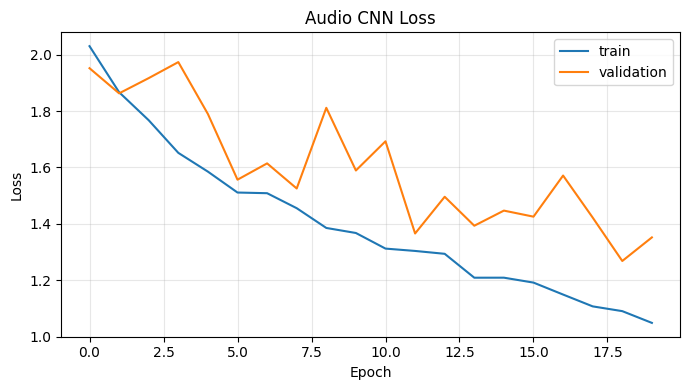

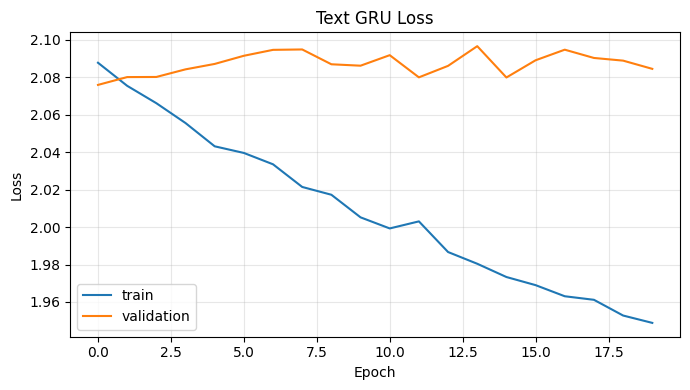

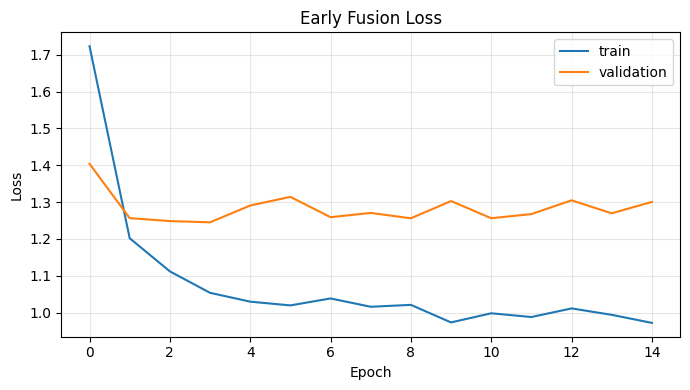

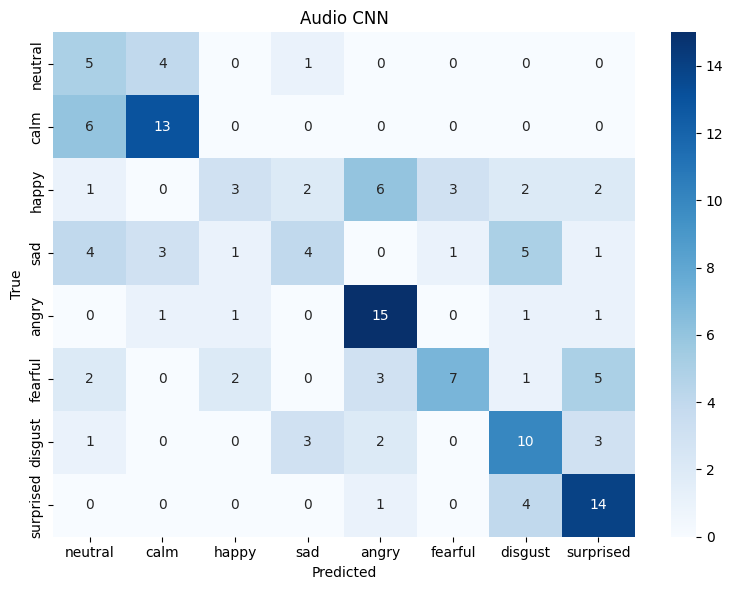

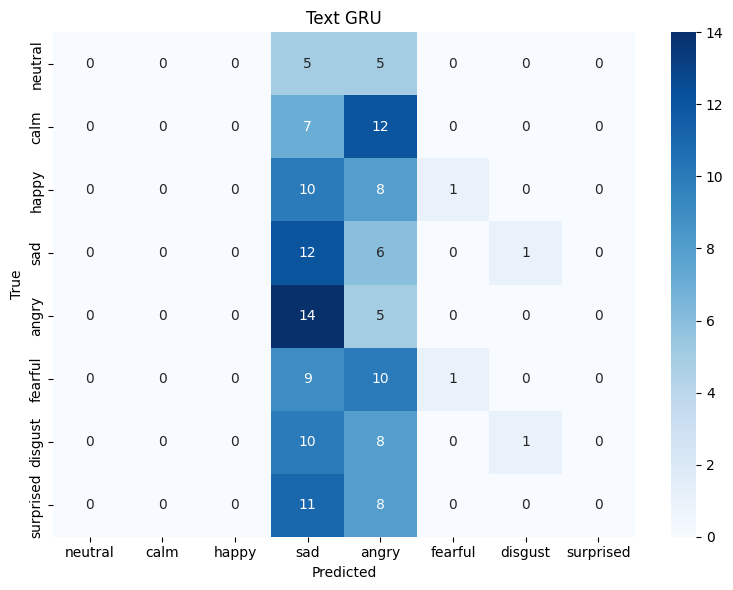

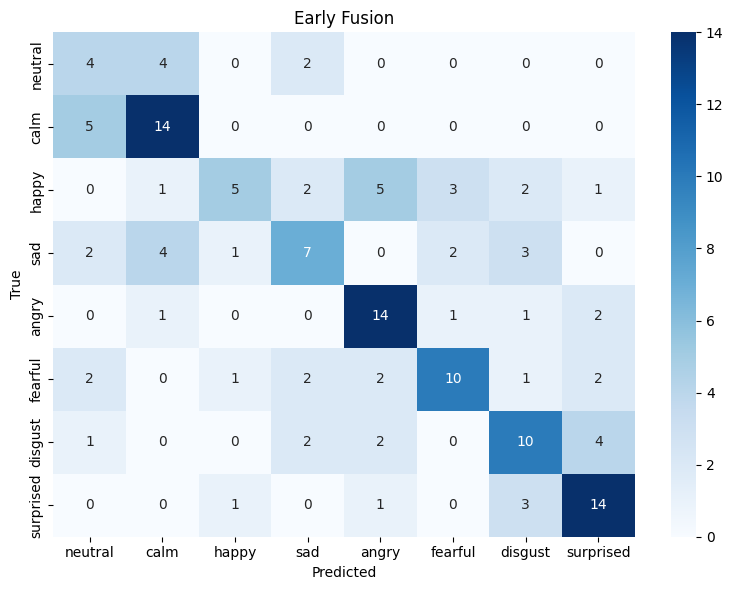

In [11]:
mer.plot_training_history(audio_history, title="Audio CNN Loss")
mer.plot_training_history(text_history, title="Text GRU Loss")
mer.plot_training_history(fusion_history, title="Early Fusion Loss")

mer.plot_confusion_matrix(results["Audio CNN"]["confusion_matrix"], title="Audio CNN")
mer.plot_confusion_matrix(results["Text GRU"]["confusion_matrix"], title="Text GRU")
mer.plot_confusion_matrix(results["Early Fusion"]["confusion_matrix"], title="Early Fusion")

In [12]:
# Example actor holdout setup
holdout_actor = 1
actor_train_df, actor_test_df = mer.actor_holdout_split(df, holdout_actor)
print(len(actor_train_df), len(actor_test_df))

1380 60
